In [28]:
from langgraph.graph import StateGraph,START,END
from typing import TypedDict,Literal

In [29]:
class Quadstate(TypedDict):
    a:int
    b:int
    c:int
    equation:str
    discriminant:float
    result:str

In [30]:
def show_equation(state:Quadstate)->str:
    equation = f"{state['a']}x^2+{state['b']}x+{state['c']}=0"
    return {'equation':equation}
def calculate_discriminant(state:Quadstate)->float:
    discriminant = state['b']**2 - 4*state['a']*state['c']
    return {'discriminant':discriminant}
def real_roots(state:Quadstate):
    root1 = (-state['b'] + state['discriminant']**0.5)/(2*state['a'])
    root2 = (-state['b'] - state['discriminant']**0.5)/(2*state['a'])
    return {'result':f"Roots are real and distinct:{root1} and {root2}"}
def repeated_roots(state:Quadstate):
    root = state['b']/(2*state['a'])
    return {'result':f"Roots are real and repeated:{root}"}
def complex_roots(state:Quadstate):
    real_roots = -state['b']/(2*state['a'])
    imaginary_roots = (abs(state['discriminant'])**0.5)/(2*state['a'])
    return {'result':f"Roots are complex:{real_roots}+{imaginary_roots}i and {real_roots}-{imaginary_roots}i"}
def check_condition(state:Quadstate)->Literal['real_roots','repeated_roots','complex_roots']:
    if state['discriminant']>0:
        return 'real_roots'
    elif state['discriminant']==0:
        return 'repeated_roots'
    else:
        return 'complex_roots'


In [ ]:
graph = StateGraph(Quadstate)
graph.add_node('show_equation',show_equation)
graph.add_node('calculate_discriminant',calculate_discriminant)
graph.add_node('real_roots',real_roots)
graph.add_node('repeated_roots',repeated_roots)
graph.add_node('complex_roots',complex_roots)
graph.add_edge(START,'show_equation')
graph.add_edge('show_equation','calculate_discriminant')
graph.add_conditional_edges('calculate_discriminant',check_condition)
graph.add_edge('real_roots',END)
graph.add_edge('repeated_roots',END)
graph.add_edge('complex_roots',END)
workflow=graph.compile() 

In [32]:
initial_state = {
    'a':3,
    "b":4,
    'c':5
}
workflow.invoke(initial_state)

{'a': 3,
 'b': 4,
 'c': 5,
 'equation': '3x^2+4x+5=0',
 'discriminant': -44,
 'result': 'Roots are complex:-0.6666666666666666+1.1055415967851332i and -0.6666666666666666-1.1055415967851332i'}

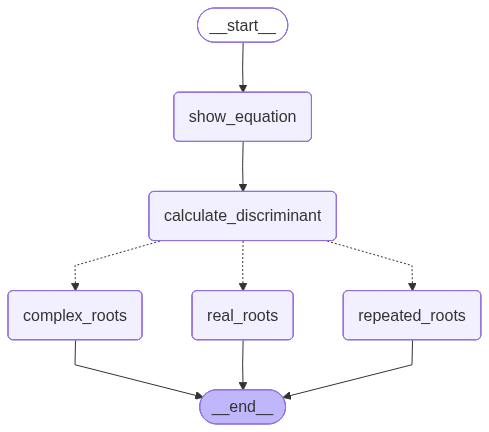

In [33]:
workflow